## System RUL

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed

from experiment_config import (
    SEED,
    UNCERTAINTY_LEVEL,
    DegModel,
    dataset_paths,
    load_baseline_gains,
    pfnet_paths,
)
from src.helpers.seed import set_global_seed
from src.helpers.visualization import plot_rul_from_dataframe
from src.models.networks.pf_mlp import ParticleFilterMLP, build_activation
from src.models.particle_filter.core import ParticleFilter
from src.models.rul_predictor import RULPredictor
from src.training.pfnet_hparams import PFNET_ARGS

# CPUs allocated by SLURM (fallback 4); repetitions run in parallel across these
N_CPUS = int(os.environ.get("SLURM_CPUS_PER_TASK") or 1)

N_CPUS


10

## Configuration

In [2]:
DATA_NAME = "DS01"
ARGS_ID = 0
N_REP = 10

## Parameters

In [3]:
## Plot resolution
t_grid = np.linspace(0.1, 100, 80)
s_grid = np.linspace(0.0, 1.0, 60)

In [4]:
set_global_seed(SEED)
ESTIMATION_DIR, DEGR_MODEL_DIR = dataset_paths(
    DATA_NAME, fields=["estimation", "degr_model"]
)
# Select the trained hyperparameter set for this run (must match training).

args = PFNET_ARGS[ARGS_ID]
net_args = args["NETWORK"]
USE_NET = net_args is not None  # net_args None -> no-network PF baseline
pf_args = args["PARTICLE_FILTER"]

PFNET_ARGS_DIR, PRED_DIR = pfnet_paths(ARGS_ID, DATA_NAME)

# keep the online (re-run) outputs separate from the from_perform reconstruction
PRED_DIR = PRED_DIR / "online"
PRED_DIR.mkdir(parents=True, exist_ok=True)


## Load pf-models

In [5]:
hi_df = pd.read_csv(ESTIMATION_DIR / "data_dev.csv")
dev_units = hi_df["unit"].astype(int).unique().tolist()
perform_names = [col for col in hi_df.columns if col not in ["unit", "cycle", "hs"]]
del hi_df

dev_units

[1, 2, 4, 5, 6]

In [6]:
pfs = {}
for perform_name in perform_names:
    # load pf-network
    if USE_NET:
        net = ParticleFilterMLP(
            state_dim=DegModel.state_dim(),
            hidden_dims=list(net_args["HIDDEN_DIMS"]),
            activation=build_activation(net_args),
            dropout_p=float(net_args["DROPOUT"]),
        )
        ckpt = torch.load(
            PFNET_ARGS_DIR / perform_name / "checkpoint_best.pt", weights_only=False
        )
        net.load_state_dict(ckpt["model_state"])
        net = net.eval()
    else:
        net = None

    # baseline only (net is None): per-metric constant gains tuned by Optuna
    gains = (
        load_baseline_gains(ARGS_ID, DATA_NAME, perform_name) if net is None else None
    )

    degmodels = []
    for unit in dev_units:
        best_model = DegModel()
        best_model.load_state_dict(
            torch.load(
                DEGR_MODEL_DIR
                / "states"
                / perform_name
                / f"unit_{unit}"
                / "best_model.pt"
            )
        )
        degmodels.append(best_model)

    perform_pf = ParticleFilter(
        base_models=degmodels,
        net=net,
        n_particles=int(pf_args["N_PARTICLES"]),
        max_life=int(pf_args["MAX_LIFE"]),
        use_net=USE_NET,
        const_noise=gains["NOISE"] if gains else None,
        const_prior=gains["PRIOR"] if gains else None,
        const_lik=gains["LIK"] if gains else None,
    )

    pfs[perform_name] = perform_pf


## Create System RUL

In [7]:
rul_pred = RULPredictor(
    pf_models=pfs, conf_level=UNCERTAINTY_LEVEL, max_life=int(pf_args["MAX_LIFE"])
)

## Import test data


In [8]:
hi_df = pd.read_csv(ESTIMATION_DIR / "data_test.csv")
test_units = hi_df["unit"].astype(int).unique().tolist()
test_units

[7, 8, 9, 10]

In [9]:
performs = {
    name: {unit: hi_df[hi_df["unit"] == unit][name].values for unit in test_units}
    for name in perform_names
}
time = {unit: hi_df[hi_df["unit"] == unit]["cycle"].values for unit in test_units}
onsets = {
    unit: hi_df[(hi_df["unit"] == unit) & (hi_df["hs"] == 0)]["cycle"].values[0]
    for unit in test_units
}

del hi_df["hs"]

## Prepare data

In [10]:
test_data = {}
for name, perform_units in performs.items():
    test_perform_data = {}
    for unit in test_units:
        t_data = time[unit]
        s_data = perform_units[unit]
        test_perform_data[unit] = torch.tensor(
            np.stack([t_data, s_data], axis=1), dtype=torch.float32
        )
    test_data[name] = test_perform_data

## Preditc RUL

In [ ]:
# Each repetition is independent (own seed + own output file), so run them in
# parallel across CPUs. Existing rep files are skipped (crash-safe / resumable).
# Aggregation across reps happens in 7-results.ipynb (globs the folder).
n_workers = max(1, min(N_REP, N_CPUS))
threads_per_worker = max(1, N_CPUS // n_workers)


def run_rep(rep):
    rep_path = PRED_DIR / f"rul_test_r{rep}.csv"
    if rep_path.exists():
        return f"rep {rep + 1}/{N_REP}: already saved ({rep_path.name})"

    # split cores across workers so processes don't oversubscribe the node
    torch.set_num_threads(threads_per_worker)
    # per-rep seed makes each repetition reproducible and order-independent
    set_global_seed(SEED + rep)

    rul_pred = RULPredictor(
        pf_models=pfs, conf_level=UNCERTAINTY_LEVEL, max_life=int(pf_args["MAX_LIFE"])
    )
    rul_pred.reset()

    rep_dfs = []
    for test_unit in test_units:
        s_data = {name: performs[name][test_unit] for name in perform_names}
        t_data = time[test_unit]
        eol_time = time[test_unit][-1]

        rul_pred.predict(t_data=t_data, s_data=s_data)
        df = rul_pred.history_to_dataframe()
        df["rep"] = rep
        df["seed"] = SEED + rep
        df["unit"] = test_unit
        df["true_rul"] = np.maximum(eol_time - df["time"], 0.0)
        rep_dfs.append(df)

    # one self-contained file per repetition (crash-safe and parallel-safe)
    pd.concat(rep_dfs, ignore_index=True).to_csv(rep_path, index=False)
    return f"rep {rep + 1}/{N_REP}: saved {rep_path.name}"


print(f"running {N_REP} reps on {n_workers} workers x {threads_per_worker} threads")
for msg in Parallel(n_jobs=n_workers, backend="loky")(
    delayed(run_rep)(rep) for rep in range(N_REP)
):
    print(msg)


running 10 reps on 10 workers x 1 threads


# Plot final RUL predictions

In [ ]:
# aggregate all individual repetition files in the folder
rep_files = sorted(PRED_DIR.glob("rul_test_r*.csv"))

df_preds = pd.concat((pd.read_csv(f) for f in rep_files), ignore_index=True)
print(f"loaded {len(rep_files)} repetition files")
PRED_DIR

loaded 10 repetition files


PosixPath('/lustre/diazgonz/deep-performance-rul/experiments/DS01/opcond_q0.001-0.999_corr0.6_range0.6/estimation_thr0.2/gamma/net_arg0/pred_ulevel0.95')

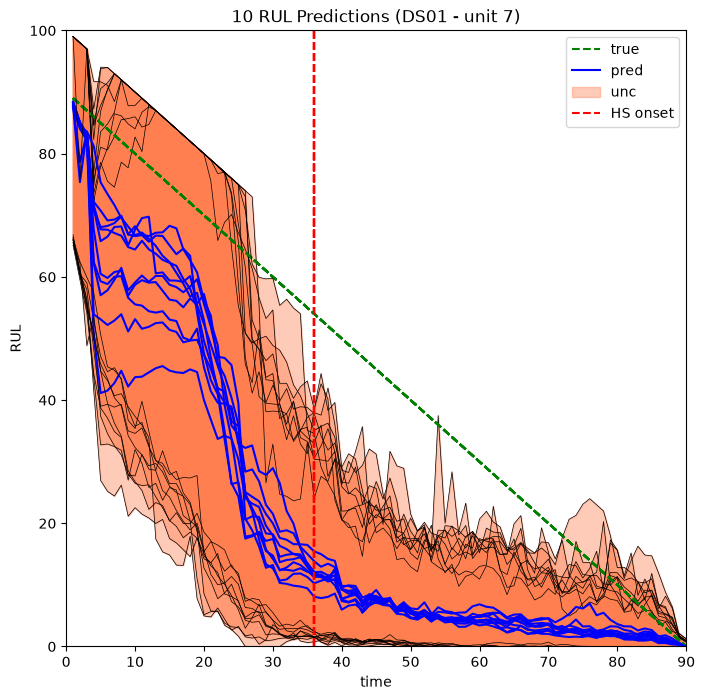

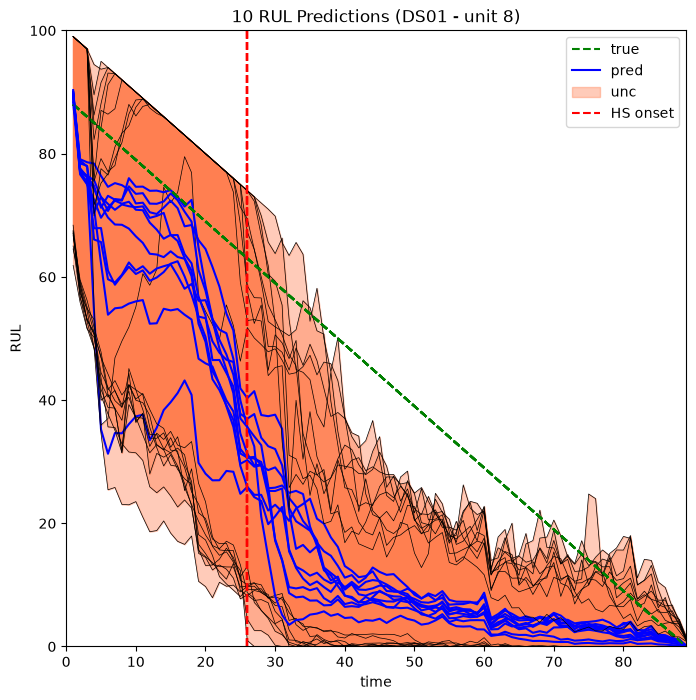

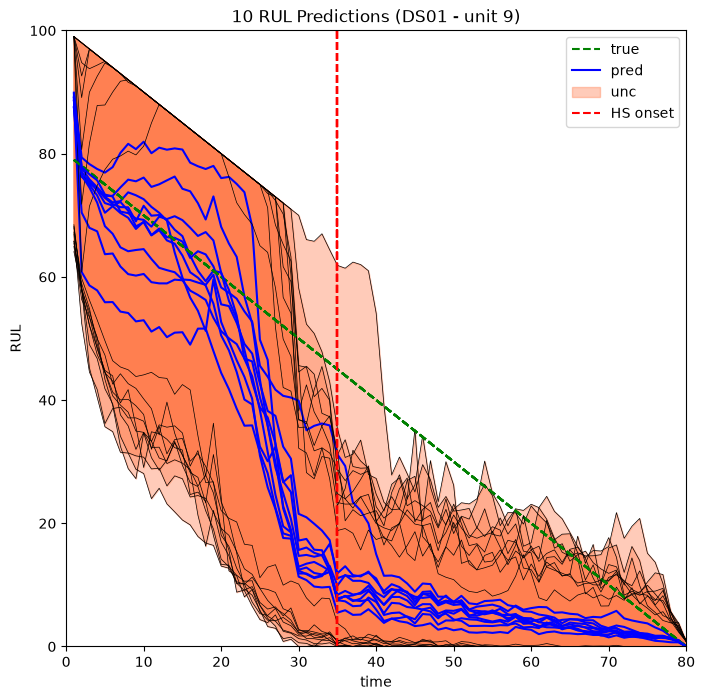

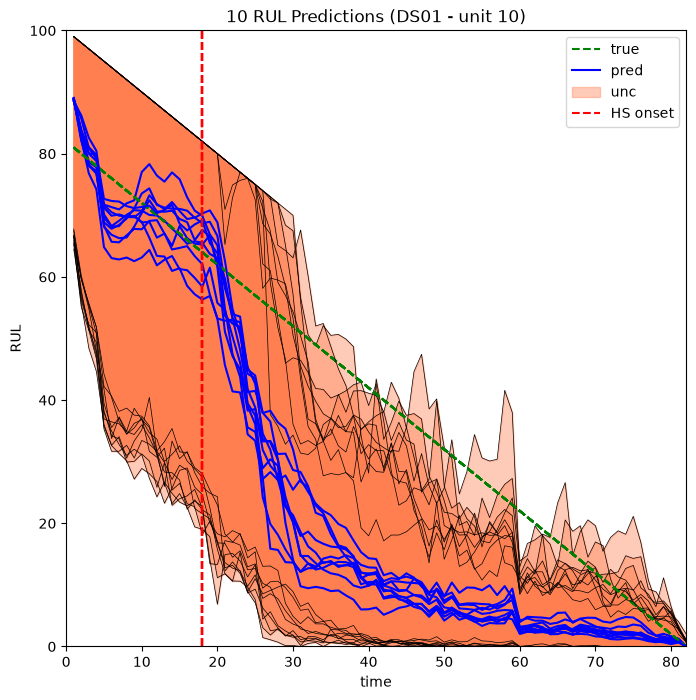

In [ ]:
for unit in test_units:
    fig, ax = plt.subplots(figsize=(8, 8))
    for rep in range(N_REP):
        df = df_preds[(df_preds["unit"] == unit) & (df_preds["rep"] == rep)]
        eol_time = df["time"].iloc[-1]
        plot_rul_from_dataframe(
            ax=ax,
            df=df,
            t_max=eol_time,
            title=f"{N_REP} RUL Predictions ({DATA_NAME} - unit {unit})",
            show_legend=False if rep else True,
        )
        ax.vlines(
            onsets[unit],
            ymin=0,
            ymax=100,
            colors="red",
            linestyles="dashed",
            label="HS onset" if rep == 0 else None,
        )
    ax.legend()
    fig.savefig(PRED_DIR / f"rul_test_test{unit}.png")

## inal RUL Mean Prediction

In [ ]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()

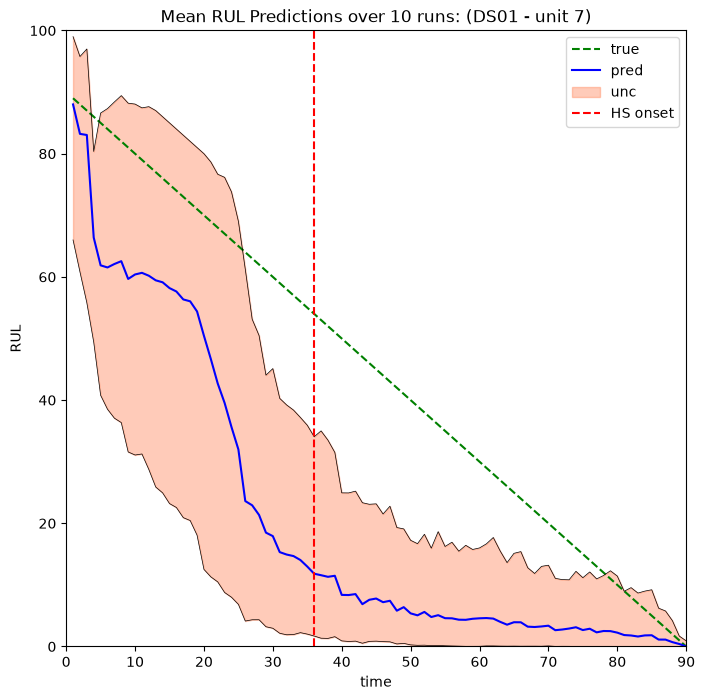

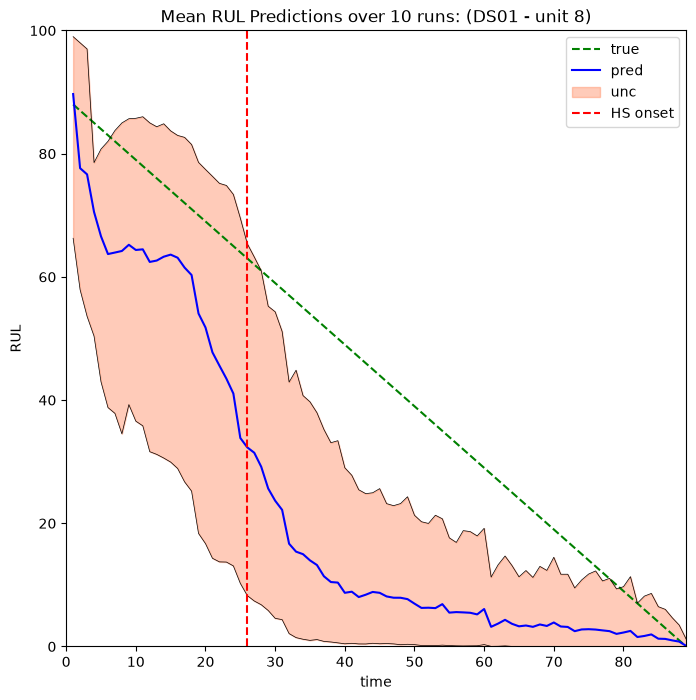

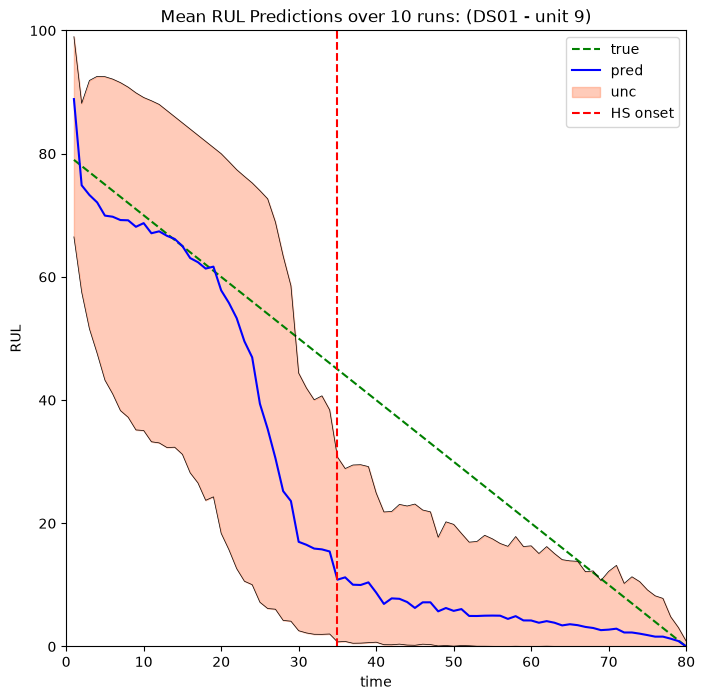

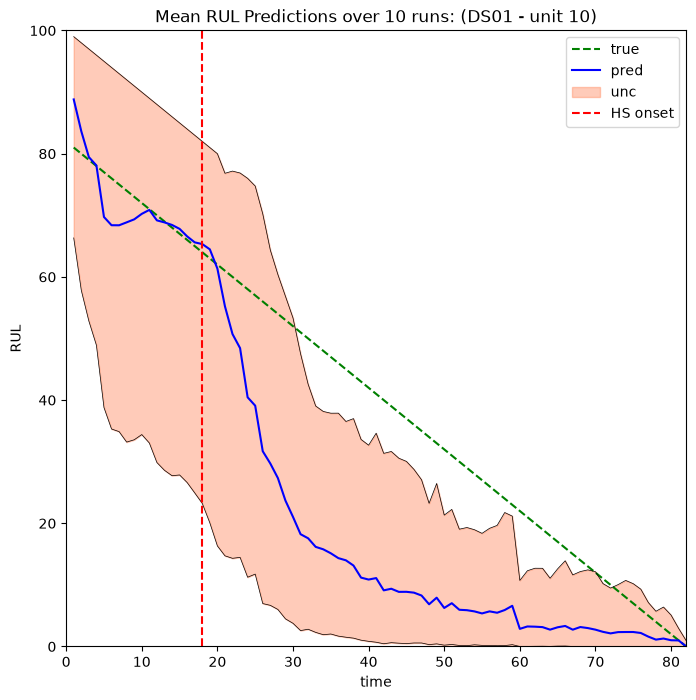

In [ ]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()
for unit in test_units:
    fig, ax = plt.subplots(figsize=(8, 8))
    df = df_preds[df_preds["unit"] == unit]
    eol_time = df["time"].iloc[-1]
    plot_rul_from_dataframe(
        ax=ax,
        df=df,
        t_max=eol_time,
        title=f"Mean RUL Predictions over {N_REP} runs: ({DATA_NAME} - unit {unit})",
        show_legend=True,
    )
    ax.vlines(
        onsets[unit],
        ymin=0,
        ymax=100,
        colors="red",
        linestyles="dashed",
        label="HS onset",
    )
    ax.legend()
    fig.savefig(PRED_DIR / f"rul_test_mean_test{unit}.png")